# Phase 1: Data Understanding & Preprocessing
## Lending Club Loan Dataset — Data Mining Project

**Mining Angle**: Cluster borrowers by risk profile using grade, income, and debt ratio.  
**Mining Rules Target**: Borrowers stating small business as loan purpose with 10+ years of employment tend to receive Grade A loans with low interest rates.

---

### Tahapan Phase 1:
1. **Data Understanding & EDA** — Explore distribusi, missing values, data types, outliers
2. **Data Cleaning** — Handle nulls, fix inconsistencies, remove duplicates
3. **Data Transformation** — Log transform, encoding, binning, standard scaling
4. **Feature Selection** — Correlation analysis & entropy measures → <10 dimensi
5. **Save & Report** — Export clean dataset & preprocessing report

---
## Step 1: Data Understanding & Exploratory Data Analysis (EDA)

### 1.1 — Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_theme(style='whitegrid', palette='viridis')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load dataset (reading ~890K records as per project requirement to prevent out-of-memory)
import numpy as np
total_rows = 2260701
sample_size = 890000
np.random.seed(42)
skip = sorted(np.random.choice(np.arange(1, total_rows + 1), size=total_rows - sample_size, replace=False))
df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False, skiprows=skip)

print(f"Dataset loaded successfully!")
print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print()
df.head(3)

Dataset loaded successfully!
Rows   : 890,000
Columns: 151
Memory : 2.47 GB



,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68476668,NaN,20000.0,20000.0,20000.0,36 months,9.17,637.58,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68466926,NaN,10000.0,10000.0,10000.0,36 months,6.49,306.45,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 — Overview Struktur Data

In [3]:
print("=" * 60)
print("DATA TYPES SUMMARY")
print("=" * 60)
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):20s} : {count} columns")

print(f"\nTotal columns: {df.shape[1]}")

DATA TYPES SUMMARY
  float64              : 113 columns
  object               : 38 columns

Total columns: 151


In [4]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS (Numeric Features)")
print("=" * 60)
df.describe().T

DESCRIPTIVE STATISTICS (Numeric Features)


,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,889991.0,15048.460968,9193.082793,500.00,8000.00,12925.00,20000.00,40000.00
funded_amnt,889991.0,15043.410832,9191.366615,500.00,8000.00,12875.00,20000.00,40000.00
funded_amnt_inv,889991.0,15024.911157,9195.186066,0.00,8000.00,12800.00,20000.00,40000.00
int_rate,889991.0,13.090269,4.842391,5.31,9.49,12.62,15.99,30.99
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,4369.0,11590.375301,7572.430439,174.15,5726.03,9921.02,15971.13,38390.38
hardship_last_payment_amount,4369.0,191.807182,197.921400,0.01,41.29,131.45,281.45,1291.21
settlement_amount,13534.0,5027.630460,3701.959276,120.00,2222.00,4166.00,6891.78,30000.00
settlement_percentage,13534.0,47.830374,7.927283,0.45,45.00,45.00,50.00,521.35


### 1.3 — Missing Values Analysis

In [5]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

total_cols = df.shape[1]
cols_no_missing = total_cols - len(missing_df)

print("MISSING VALUES SUMMARY")
print("=" * 60)
print(f"  Columns tanpa missing     : {cols_no_missing}")
print(f"  Columns dengan missing     : {len(missing_df)}")
print(f"  ├── >50% missing (DROP)    : {len(missing_df[missing_df['Missing %'] > 50])}")
print(f"  ├── 20-50% missing         : {len(missing_df[(missing_df['Missing %'] > 20) & (missing_df['Missing %'] <= 50)])}")
print(f"  └── <20% missing (IMPUTE)  : {len(missing_df[missing_df['Missing %'] <= 20])}")

print("\nAll columns with missing values:")
display(missing_df)

MISSING VALUES SUMMARY
  Columns tanpa missing     : 1
  Columns dengan missing     : 150
  ├── >50% missing (DROP)    : 44
  ├── 20-50% missing         : 14
  └── <20% missing (IMPUTE)  : 92

All columns with missing values:


,Missing Count,Missing %
member_id,890000,100.00
orig_projected_additional_accrued_interest,886542,99.61
hardship_payoff_balance_amount,885631,99.51
hardship_last_payment_amount,885631,99.51
payment_plan_start_date,885631,99.51
...,...,...
total_rec_int,9,0.00
earliest_cr_line,23,0.00
hardship_flag,9,0.00
disbursement_method,9,0.00


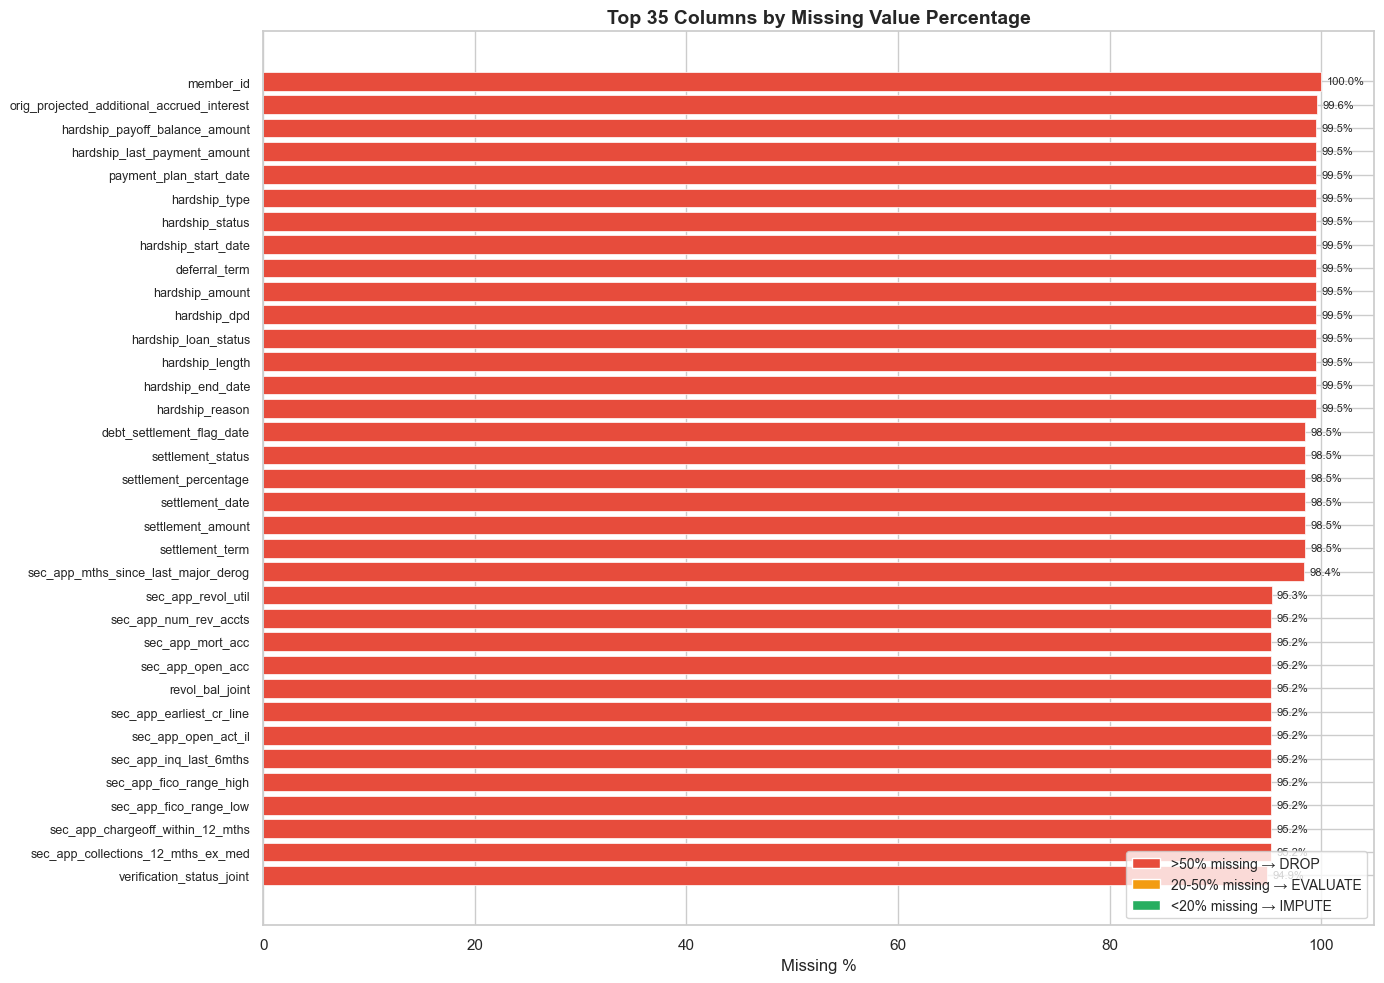

In [6]:
# Visualisasi Missing Values
fig, ax = plt.subplots(figsize=(14, 10))
top_missing = missing_df.head(35)

colors = []
for pct in top_missing['Missing %']:
    if pct > 50:
        colors.append('#e74c3c')   # merah — akan di-drop
    elif pct > 20:
        colors.append('#f39c12')   # orange — evaluasi
    else:
        colors.append('#27ae60')   # hijau — impute

bars = ax.barh(range(len(top_missing)), top_missing['Missing %'].values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing.index, fontsize=9)
ax.set_xlabel('Missing %')
ax.set_title('Top 35 Columns by Missing Value Percentage', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, top_missing['Missing %'].values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='>50% missing → DROP'),
    Patch(facecolor='#f39c12', label='20-50% missing → EVALUATE'),
    Patch(facecolor='#27ae60', label='<20% missing → IMPUTE')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

### 1.4 — Distribusi Fitur Numerik

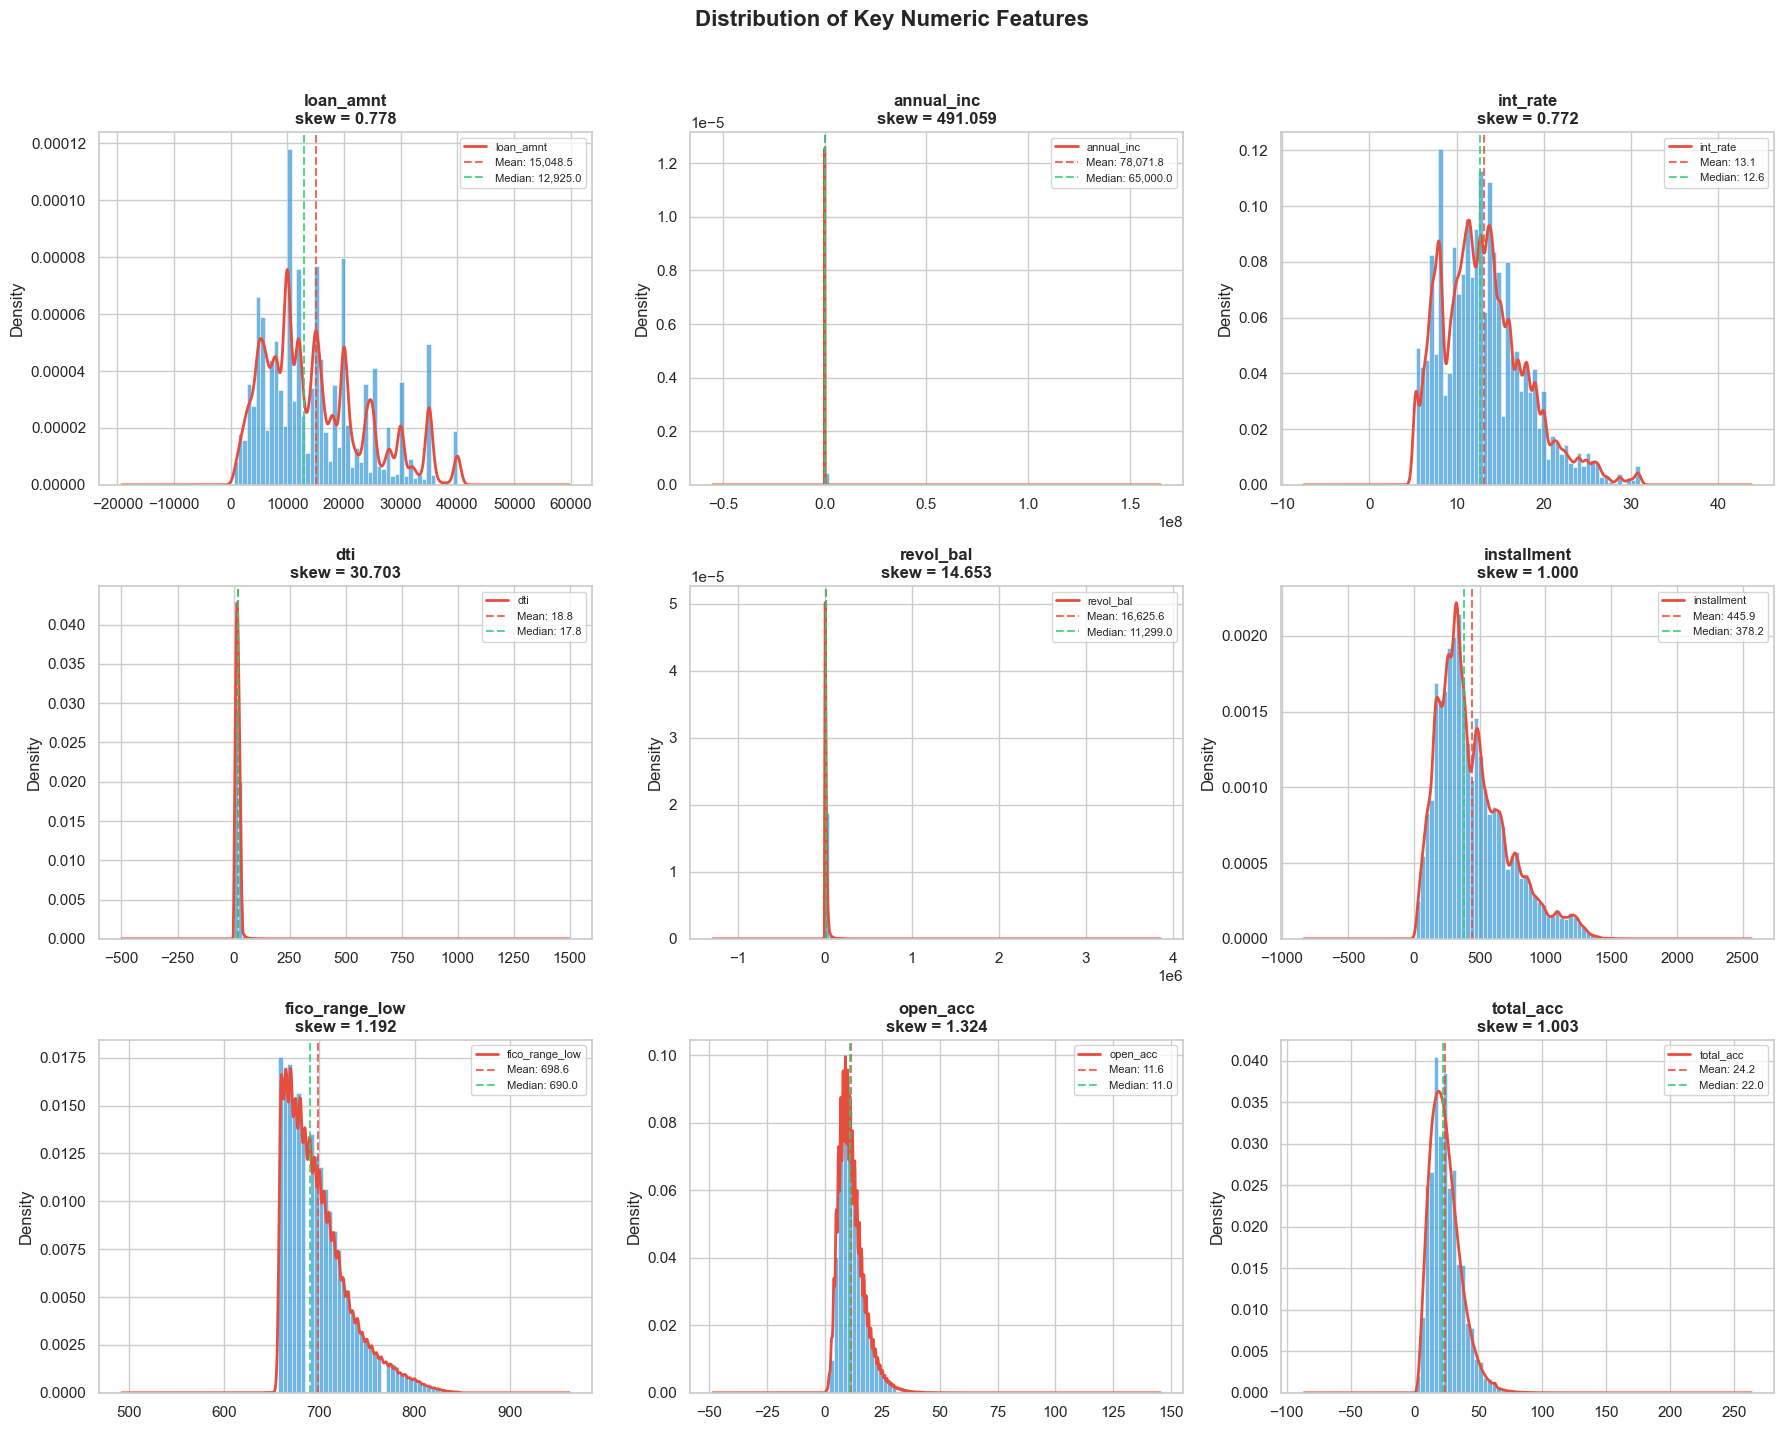


Skewness Summary:
----------------------------------------
  loan_amnt           :    0.778
  annual_inc          :  491.059 ⚠️ HIGH SKEW
  int_rate            :    0.772
  dti                 :   30.703 ⚠️ HIGH SKEW
  revol_bal           :   14.653 ⚠️ HIGH SKEW
  installment         :    1.000
  fico_range_low      :    1.192
  open_acc            :    1.324
  total_acc           :    1.003


In [7]:
# Histogram & KDE untuk fitur-fitur kunci
key_numeric = ['loan_amnt', 'annual_inc', 'int_rate', 'dti', 'revol_bal',
               'installment', 'fico_range_low', 'open_acc', 'total_acc']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for i, col in enumerate(key_numeric):
    ax = axes[i // 3, i % 3]
    data = df[col].dropna()
    ax.hist(data, bins=50, alpha=0.7, color='#3498db', edgecolor='white', linewidth=0.5, density=True)
    data.plot.kde(ax=ax, color='#e74c3c', linewidth=2)
    ax.axvline(data.mean(), color='#e74c3c', linestyle='--', alpha=0.8, label=f'Mean: {data.mean():,.1f}')
    ax.axvline(data.median(), color='#2ecc71', linestyle='--', alpha=0.8, label=f'Median: {data.median():,.1f}')
    ax.set_title(f'{col}\nskew = {data.skew():.3f}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Numeric Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print skewness summary
print("\nSkewness Summary:")
print("-" * 40)
for col in key_numeric:
    skew = df[col].skew()
    flag = " ⚠️ HIGH SKEW" if abs(skew) > 1.5 else ""
    print(f"  {col:20s}: {skew:8.3f}{flag}")

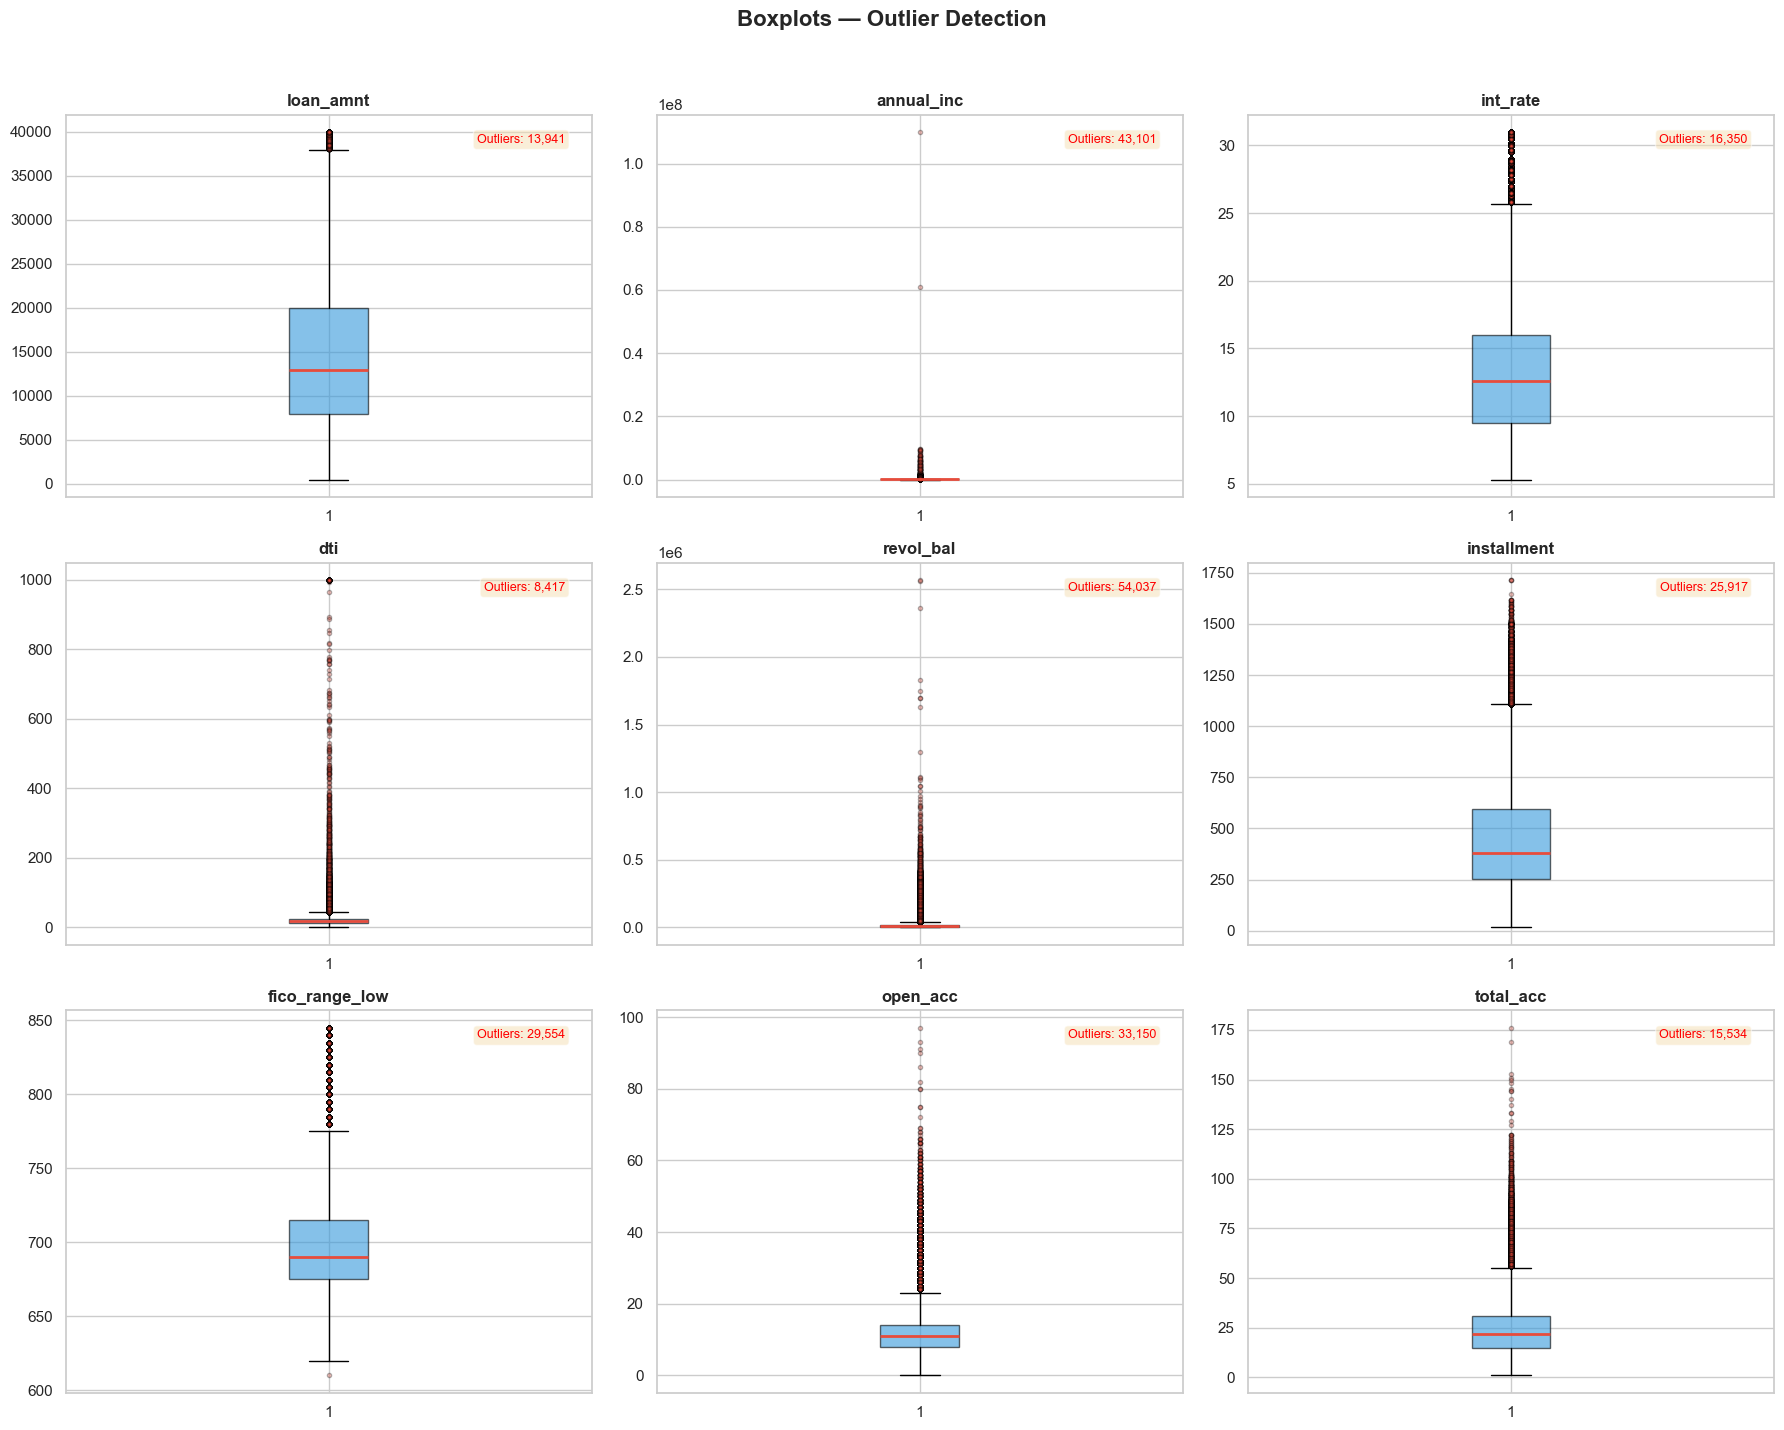

In [8]:
# Boxplot untuk deteksi outliers
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for i, col in enumerate(key_numeric):
    ax = axes[i // 3, i % 3]
    data = df[col].dropna()
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='#e74c3c', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.3))
    ax.set_title(col, fontweight='bold')

    # Count outliers (IQR method)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).sum()
    ax.text(0.95, 0.95, f'Outliers: {outliers:,}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='red',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Boxplots — Outlier Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.5 — Distribusi Fitur Kategorik

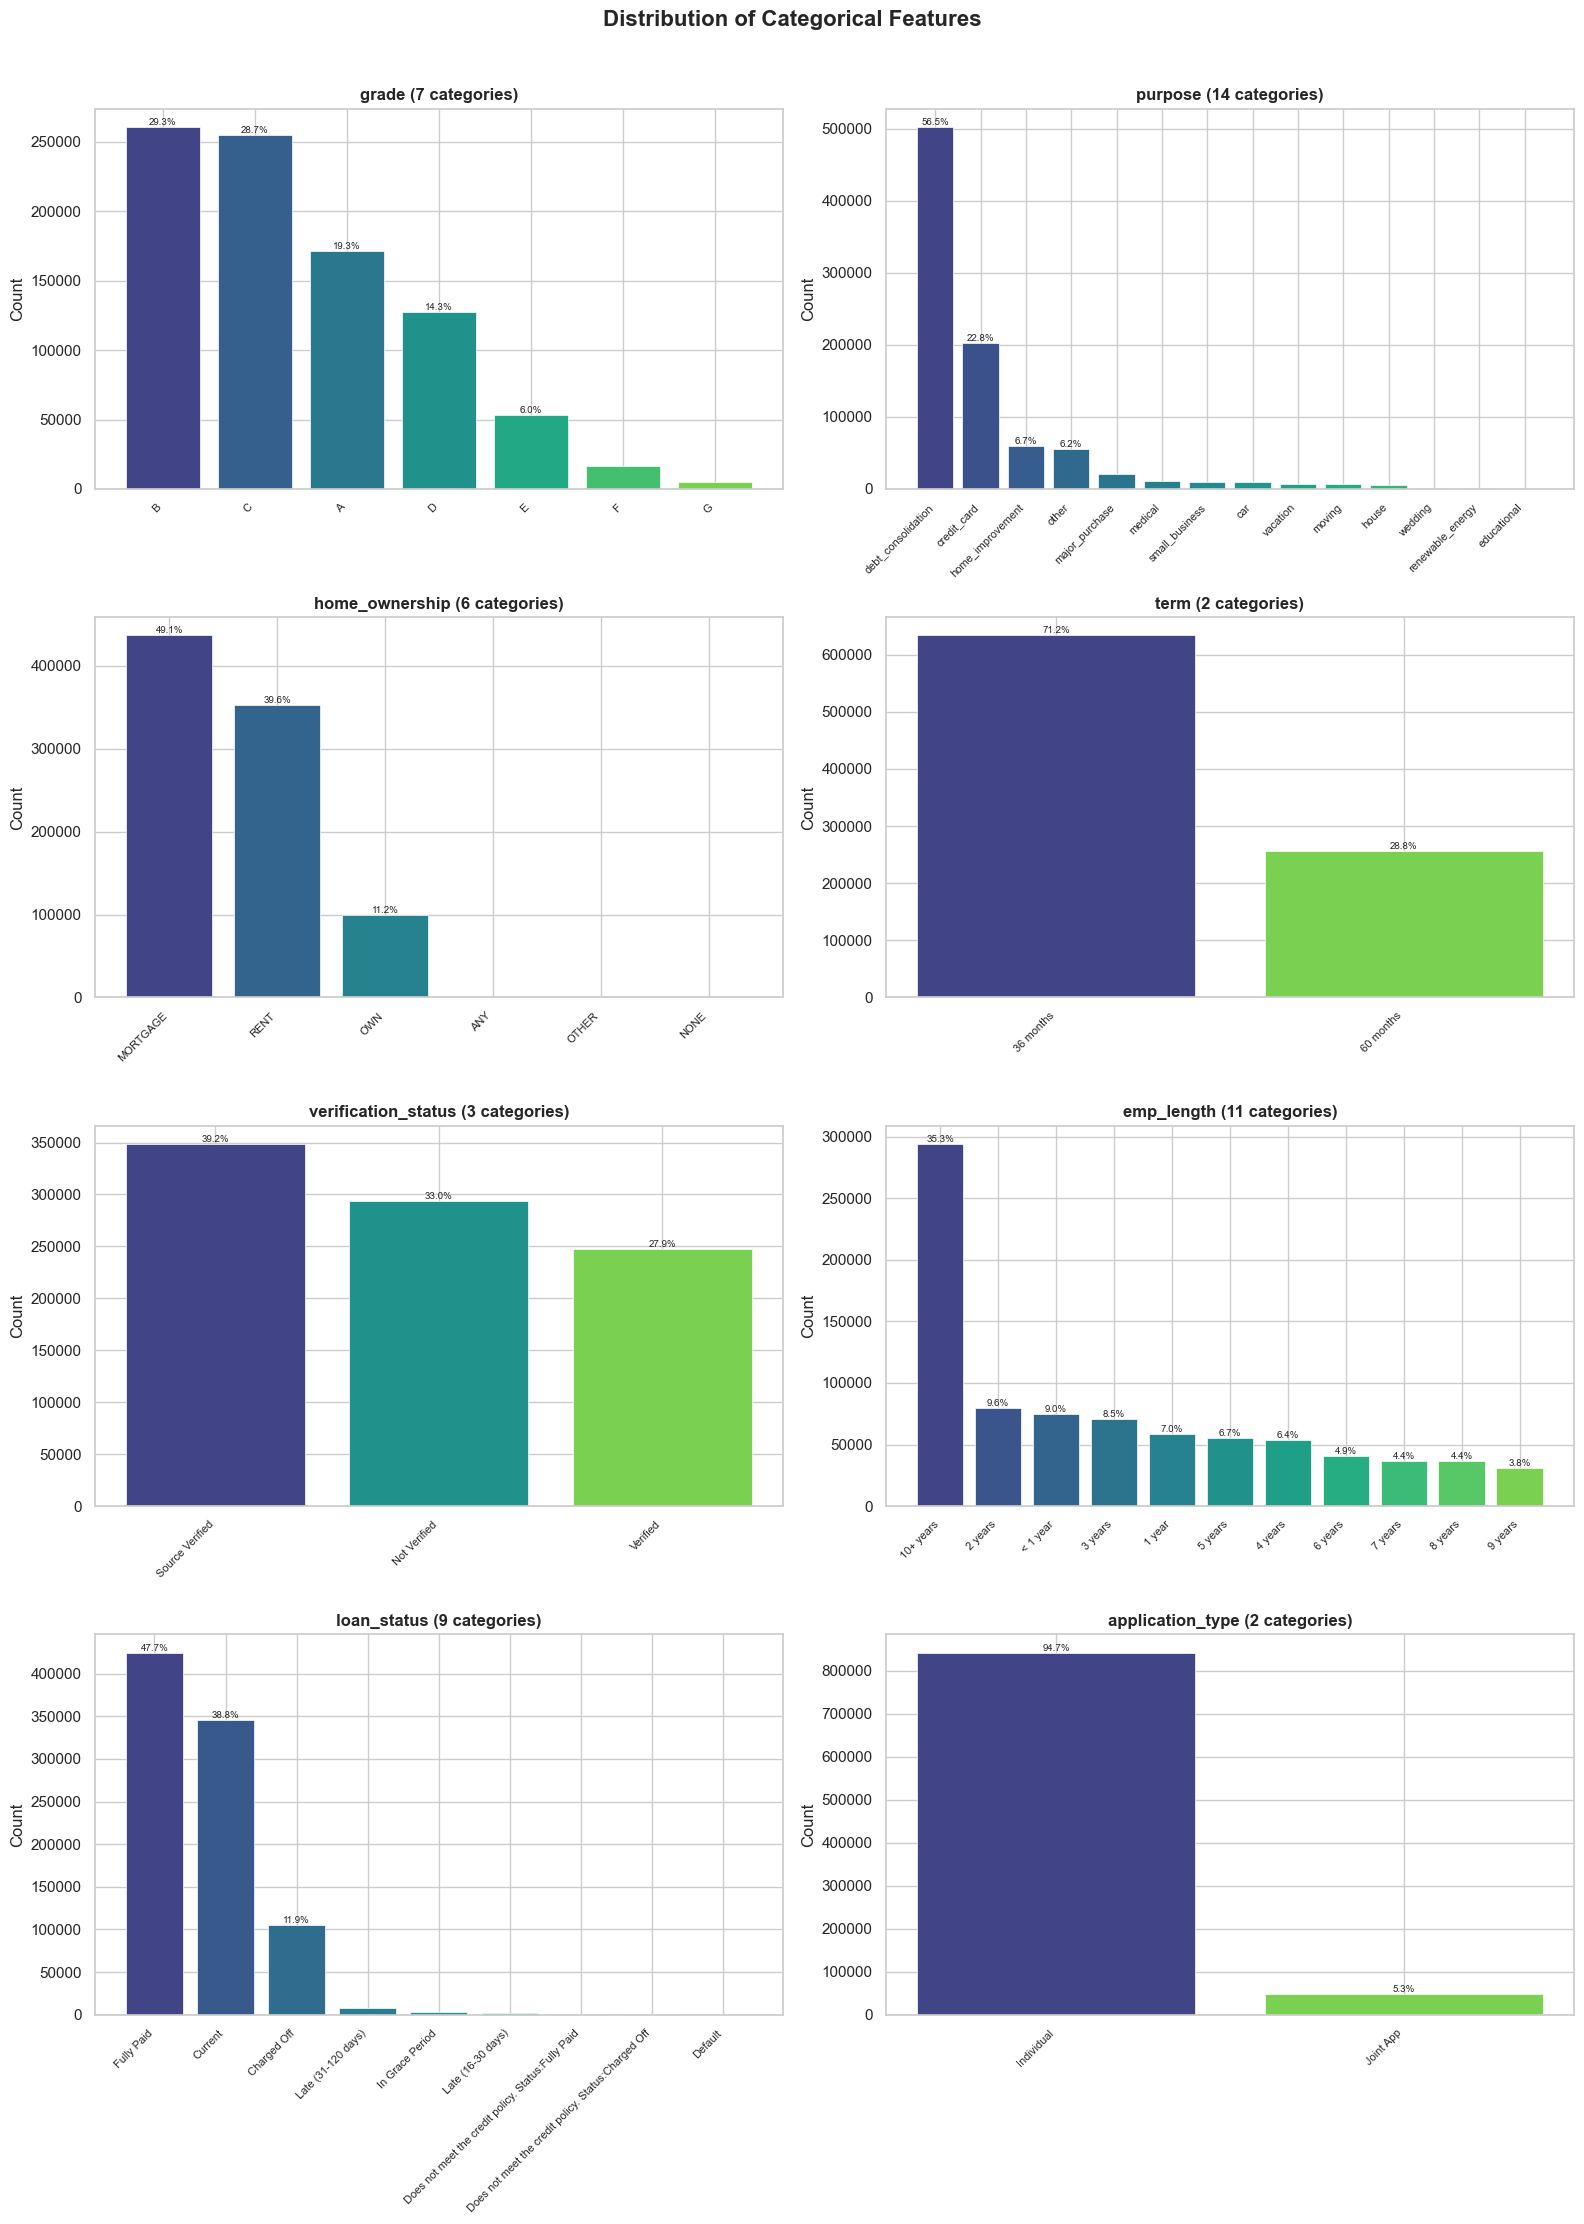

In [9]:
cat_cols = ['grade', 'purpose', 'home_ownership', 'term',
            'verification_status', 'emp_length', 'loan_status', 'application_type']

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    counts = df[col].value_counts()
    n_cats = len(counts)
    palette = plt.cm.viridis(np.linspace(0.2, 0.8, n_cats))
    bars = ax.bar(range(n_cats), counts.values, color=palette, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(n_cats))
    ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{col} ({n_cats} categories)', fontweight='bold')
    ax.set_ylabel('Count')

    # Add percentage labels
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        if pct > 3:  # Only label if > 3%
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)

plt.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.6 — Correlation Analysis (Awal)

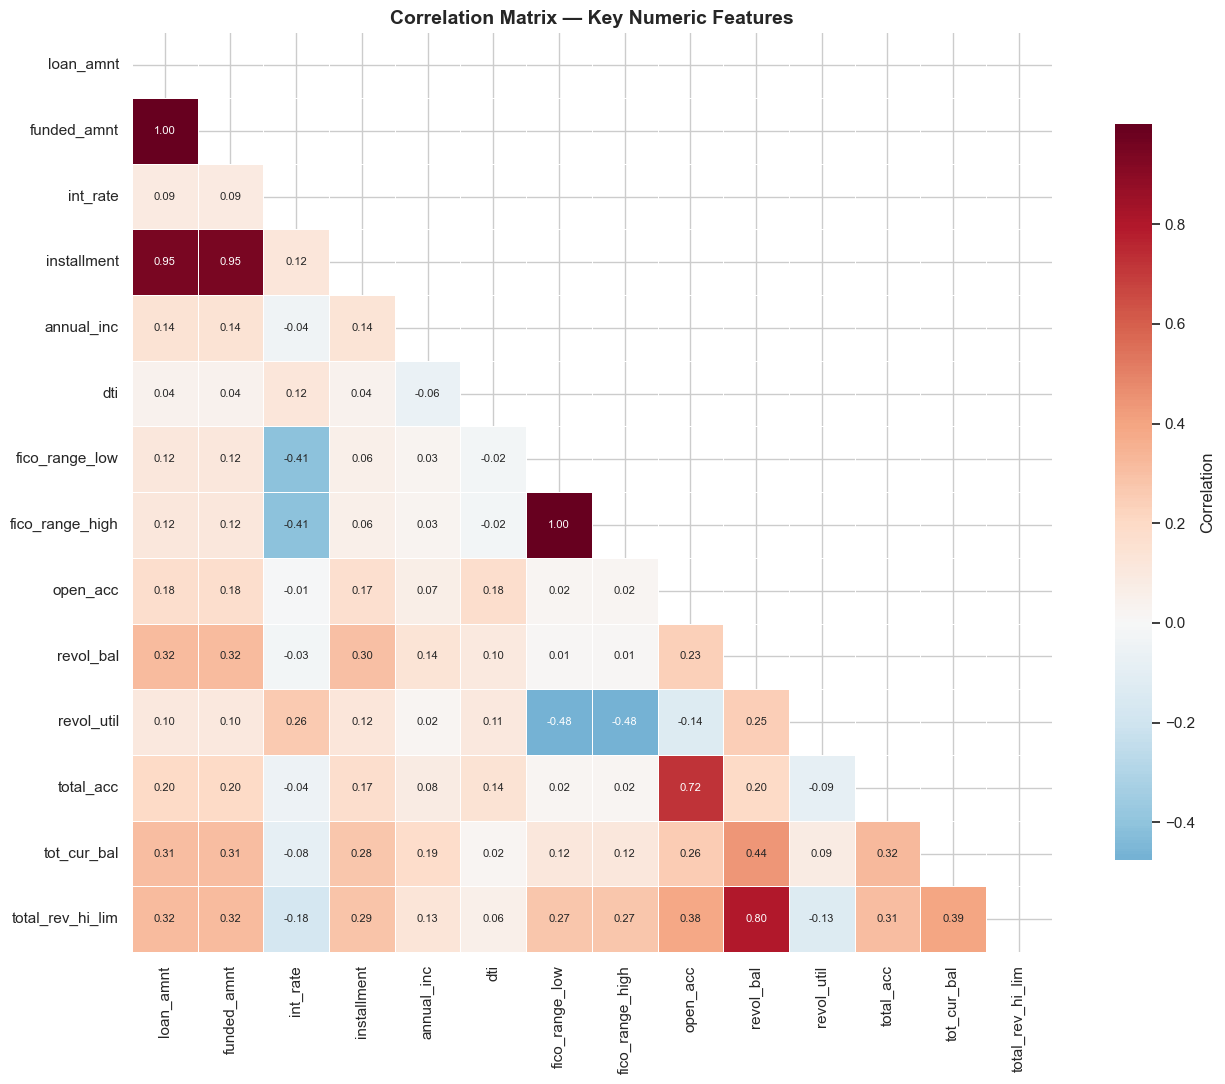


Highly Correlated Pairs (|r| > 0.80):
  loan_amnt                 vs funded_amnt               : r = 1.000
  loan_amnt                 vs installment               : r = 0.946
  funded_amnt               vs installment               : r = 0.946
  fico_range_low            vs fico_range_high           : r = 1.000


In [10]:
# Correlation matrix untuk fitur numerik kunci
corr_cols = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc',
             'dti', 'fico_range_low', 'fico_range_high', 'open_acc', 'revol_bal',
             'revol_util', 'total_acc', 'tot_cur_bal', 'total_rev_hi_lim']
corr_data = df[corr_cols].dropna()
corr = corr_data.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Key Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
print("\nHighly Correlated Pairs (|r| > 0.80):")
print("=" * 55)
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.80:
            print(f"  {corr.columns[i]:25s} vs {corr.columns[j]:25s} : r = {r:.3f}")

---
## Step 2: Data Cleaning

Tujuan: Handle nulls, fix inconsistencies, remove duplicates, drop post-loan columns.

### 2.1 — Drop Kolom dengan Missing Values >50% & Kolom Irrelevant

In [11]:
print(f"Shape SEBELUM cleaning: {df.shape}")
print("=" * 60)

# 1. Drop columns with >50% missing
high_missing_cols = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f"\n[1] Dropping {len(high_missing_cols)} columns with >50% missing values:")
for col in high_missing_cols:
    print(f"    ✗ {col} ({missing_df.loc[col, 'Missing %']}%)")
df.drop(columns=high_missing_cols, inplace=True, errors='ignore')

# 2. Drop irrelevant columns
irrelevant_cols = [
    'id',               # identifier, not a feature
    'url',              # link, not a feature
    'emp_title',        # 3000+ unique free-text values
    'title',            # redundant with 'purpose'
    'zip_code',         # too granular (700+ unique)
    'issue_d',          # loan issue date — temporal, not for clustering
    'last_pymnt_d',     # post-loan outcome
    'next_pymnt_d',     # post-loan outcome
    'last_credit_pull_d',  # post-loan outcome
    'earliest_cr_line',    # date string, hard to use directly
    'disbursement_method', # only 1 unique value (Cash)
    'pymnt_plan',          # only 1 unique value (n)
    'policy_code',         # only 1 unique value (1)
]
existing_irrelevant = [c for c in irrelevant_cols if c in df.columns]
print(f"\n[2] Dropping {len(existing_irrelevant)} irrelevant columns:")
for col in existing_irrelevant:
    print(f"    ✗ {col}")
df.drop(columns=existing_irrelevant, inplace=True, errors='ignore')

print(f"\nShape SETELAH drop columns: {df.shape}")

Shape SEBELUM cleaning: (890000, 151)

[1] Dropping 44 columns with >50% missing values:
    ✗ member_id (100.0%)
    ✗ orig_projected_additional_accrued_interest (99.61%)
    ✗ hardship_payoff_balance_amount (99.51%)
    ✗ hardship_last_payment_amount (99.51%)
    ✗ payment_plan_start_date (99.51%)
    ✗ hardship_type (99.51%)
    ✗ hardship_status (99.51%)
    ✗ hardship_start_date (99.51%)
    ✗ deferral_term (99.51%)
    ✗ hardship_amount (99.51%)
    ✗ hardship_dpd (99.51%)
    ✗ hardship_loan_status (99.51%)
    ✗ hardship_length (99.51%)
    ✗ hardship_end_date (99.51%)
    ✗ hardship_reason (99.51%)
    ✗ debt_settlement_flag_date (98.48%)
    ✗ settlement_status (98.48%)
    ✗ settlement_percentage (98.48%)
    ✗ settlement_date (98.48%)
    ✗ settlement_amount (98.48%)
    ✗ settlement_term (98.48%)
    ✗ sec_app_mths_since_last_major_derog (98.42%)
    ✗ sec_app_revol_util (95.32%)
    ✗ sec_app_num_rev_accts (95.24%)
    ✗ sec_app_mort_acc (95.24%)
    ✗ sec_app_open_acc (9

### 2.2 — Remove Duplicate Rows

In [12]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count:,}")

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"After removing duplicates: {df.shape}")
else:
    print("No duplicates found. ✓")

Duplicate rows found: 8
After removing duplicates: (889992, 95)


### 2.3 — Fix Inconsistencies

In [13]:
print("Fixing data inconsistencies...")
print("=" * 60)

# 1. term: " 36 months" -> 36 (integer)
if 'term' in df.columns:
    df['term'] = pd.to_numeric(df['term'].astype(str).str.strip().str.replace(' months', '', regex=False), errors='coerce').astype('Int64')
    print(f"  ✓ term → integer: {sorted(df['term'].dropna().unique())}")

# 2. int_rate: ensure numeric (kadang stored as string with %)
if 'int_rate' in df.columns:
    if df['int_rate'].dtype == 'object':
        df['int_rate'] = pd.to_numeric(df['int_rate'].astype(str).str.replace('%', '', regex=False), errors='coerce')
        print(f"  ✓ int_rate → converted from string to float")
    else:
        print(f"  ✓ int_rate → already numeric ({df['int_rate'].dtype})")

# 3. revol_util: ensure numeric
if 'revol_util' in df.columns:
    if df['revol_util'].dtype == 'object':
        df['revol_util'] = pd.to_numeric(df['revol_util'].astype(str).str.replace('%', '', regex=False), errors='coerce')
        print(f"  ✓ revol_util → converted from string to float")
    else:
        print(f"  ✓ revol_util → already numeric ({df['revol_util'].dtype})")

# 4. emp_length: convert to numeric ordinal
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
if 'emp_length' in df.columns:
    df['emp_length'] = df['emp_length'].map(emp_map)
    print(f"  ✓ emp_length → ordinal: {sorted(df['emp_length'].dropna().unique().astype(int))}")

print("\nData types after fixes:")
check_cols = ['term', 'int_rate', 'revol_util', 'emp_length']
for col in check_cols:
    if col in df.columns:
        print(f"  {col:20s} → {df[col].dtype}")


Fixing data inconsistencies...
  ✓ term → integer: [np.int64(36), np.int64(60)]
  ✓ int_rate → already numeric (float64)
  ✓ revol_util → already numeric (float64)
  ✓ emp_length → ordinal: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Data types after fixes:
  term                 → Int64
  int_rate             → float64
  revol_util           → float64
  emp_length           → float64


### 2.4 — Handle Missing Values (Remaining Columns)

In [14]:
# Check remaining missing values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
remaining_missing_pct = (remaining_missing / len(df) * 100).round(2)

print(f"Columns still with missing values: {len(remaining_missing)}")
print("=" * 60)
for col in remaining_missing.index:
    print(f"  {col:35s}: {remaining_missing[col]:>8,} ({remaining_missing_pct[col]:>5.1f}%) [{df[col].dtype}]")

Columns still with missing values: 95
  il_util                            :  420,970 ( 47.3%) [float64]
  mths_since_rcnt_il                 :  358,730 ( 40.3%) [float64]
  all_util                           :  341,473 ( 38.4%) [float64]
  open_rv_12m                        :  341,390 ( 38.4%) [float64]
  open_il_12m                        :  341,390 ( 38.4%) [float64]
  inq_last_12m                       :  341,390 ( 38.4%) [float64]
  total_cu_tl                        :  341,390 ( 38.4%) [float64]
  open_il_24m                        :  341,390 ( 38.4%) [float64]
  open_rv_24m                        :  341,390 ( 38.4%) [float64]
  open_act_il                        :  341,390 ( 38.4%) [float64]
  total_bal_il                       :  341,390 ( 38.4%) [float64]
  open_acc_6m                        :  341,390 ( 38.4%) [float64]
  inq_fi                             :  341,390 ( 38.4%) [float64]
  max_bal_bc                         :  341,390 ( 38.4%) [float64]
  mths_since_recent_inq 

In [15]:
# Impute numeric columns with median
numeric_cols_with_na = [col for col in remaining_missing.index
                        if df[col].dtype in ['float64', 'int64', 'float32', 'int32', 'Float64']]

print(f"Imputing {len(numeric_cols_with_na)} numeric columns with MEDIAN:")
print("-" * 60)
for col in numeric_cols_with_na:
    median_val = df[col].median()
    na_count = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"  {col:35s}: {na_count:>8,} filled with median = {median_val:>10.2f}")

# Handle remaining categorical missing values
remaining_after = df.isnull().sum()
remaining_after = remaining_after[remaining_after > 0]

if len(remaining_after) > 0:
    print(f"\nStill {len(remaining_after)} columns with missing values (non-numeric):")
    for col in remaining_after.index:
        print(f"  {col}: {remaining_after[col]:,} missing ({df[col].dtype})")

    # Drop remaining rows with NaN
    before_rows = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    dropped = before_rows - len(df)
    print(f"\n  Dropped {dropped:,} rows ({dropped/before_rows*100:.2f}%) with remaining NaN")

print(f"\n✓ Missing values remaining: {df.isnull().sum().sum()}")
print(f"  Shape: {df.shape}")

Imputing 83 numeric columns with MEDIAN:
------------------------------------------------------------
  il_util                            :  420,970 filled with median =      72.00
  mths_since_rcnt_il                 :  358,730 filled with median =      13.00
  all_util                           :  341,473 filled with median =      58.00
  open_rv_12m                        :  341,390 filled with median =       1.00
  open_il_12m                        :  341,390 filled with median =       0.00
  inq_last_12m                       :  341,390 filled with median =       1.00
  total_cu_tl                        :  341,390 filled with median =       0.00
  open_il_24m                        :  341,390 filled with median =       1.00
  open_rv_24m                        :  341,390 filled with median =       2.00
  open_act_il                        :  341,390 filled with median =       2.00
  total_bal_il                       :  341,390 filled with median =   23131.00
  open_acc_6m     

### 2.5 — Outlier Detection & Handling (Winsorization)

In [16]:
# Extract non-winsorized data for Phase 2 & 4
df_no_winsor = df.copy()
print("Saved raw dataset (before winsorization) to df_no_winsor")

Saved raw dataset (before winsorization) to df_no_winsor


In [17]:
# Fitur yang sangat skewed → Winsorize (cap di persentil 1 & 99)
skewed_features = ['annual_inc', 'revol_bal', 'dti', 'tot_coll_amt', 'tot_cur_bal',
                   'avg_cur_bal', 'bc_open_to_buy', 'delinq_amnt']
skewed_features = [col for col in skewed_features if col in df.columns]

print("Outlier Handling — Winsorization (cap at 1st & 99th percentile)")
print("=" * 75)
print(f"{'Feature':25s} {'Before Range':30s} {'After Range':30s} {'Skew Before':>12s} {'Skew After':>12s}")
print("-" * 110)

for col in skewed_features:
    p1 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    before_min, before_max = df[col].min(), df[col].max()
    before_skew = df[col].skew()

    df[col] = df[col].clip(lower=p1, upper=p99)

    after_min, after_max = df[col].min(), df[col].max()
    after_skew = df[col].skew()

    print(f"  {col:23s} [{before_min:>10,.1f}, {before_max:>10,.1f}]  →  [{after_min:>10,.1f}, {after_max:>10,.1f}]   {before_skew:>8.3f}     {after_skew:>8.3f}")

Outlier Handling — Winsorization (cap at 1st & 99th percentile)
Feature                   Before Range                   After Range                     Skew Before   Skew After
--------------------------------------------------------------------------------------------------------------
  annual_inc              [       0.0, 110,000,000.0]  →  [  16,722.0,  272,000.0]    491.060        1.810
  revol_bal               [       0.0, 2,568,995.0]  →  [     122.0,   97,613.6]     14.653        2.549
  dti                     [       0.0,      999.0]  →  [       1.7,       42.5]     30.715        0.337
  tot_coll_amt            [       0.0, 9,152,545.0]  →  [       0.0,    4,523.1]    672.788        5.764
  tot_cur_bal             [       0.0, 9,971,659.0]  →  [   2,755.9,  683,623.1]      3.253        1.544
  avg_cur_bal             [       0.0,  958,084.0]  →  [     431.0,   73,888.0]      4.115        1.945
  bc_open_to_buy          [       0.0,  711,140.0]  →  [       0.0,   78,522.3]  

### 2.6 — Drop Post-Loan Outcome Columns (Data Leakage Prevention)

In [18]:
# Post-loan columns = outcomes that happen AFTER loan is issued
# These should NOT be used as features for clustering borrower profiles

post_loan_cols = [
    'funded_amnt', 'funded_amnt_inv',              # nearly identical to loan_amnt
    'out_prncp', 'out_prncp_inv',                  # outstanding principal
    'total_pymnt', 'total_pymnt_inv',              # total payment received
    'total_rec_prncp', 'total_rec_int',            # principal & interest received
    'total_rec_late_fee',                          # late fees
    'recoveries', 'collection_recovery_fee',       # recovery amounts
    'last_pymnt_amnt',                             # last payment amount
    'last_fico_range_high', 'last_fico_range_low', # FICO after loan
]

existing_post_loan = [col for col in post_loan_cols if col in df.columns]
print(f"Dropping {len(existing_post_loan)} post-loan outcome columns (data leakage prevention):")
for col in existing_post_loan:
    print(f"  ✗ {col}")
df.drop(columns=existing_post_loan, inplace=True, errors='ignore')

# Save loan_status as reference label, then remove from features
if 'loan_status' in df.columns:
    loan_status_ref = df['loan_status'].copy()
    df.drop(columns=['loan_status'], inplace=True)
    print(f"\n  ℹ loan_status saved separately as reference label (not a feature)")
    print(f"    Distribution: {dict(loan_status_ref.value_counts())}")
else:
    loan_status_ref = pd.Series(dtype='object')
    print("\n  ℹ loan_status was already removed or not present")

print(f"\nShape after removing post-loan columns: {df.shape}")

Dropping 14 post-loan outcome columns (data leakage prevention):
  ✗ funded_amnt
  ✗ funded_amnt_inv
  ✗ out_prncp
  ✗ out_prncp_inv
  ✗ total_pymnt
  ✗ total_pymnt_inv
  ✗ total_rec_prncp
  ✗ total_rec_int
  ✗ total_rec_late_fee
  ✗ recoveries
  ✗ collection_recovery_fee
  ✗ last_pymnt_amnt
  ✗ last_fico_range_high
  ✗ last_fico_range_low

  ℹ loan_status saved separately as reference label (not a feature)
    Distribution: {'Fully Paid': np.int64(424689), 'Current': np.int64(345265), 'Charged Off': np.int64(105585), 'Late (31-120 days)': np.int64(8368), 'In Grace Period': np.int64(3288), 'Late (16-30 days)': np.int64(1741), 'Does not meet the credit policy. Status:Fully Paid': np.int64(771), 'Does not meet the credit policy. Status:Charged Off': np.int64(274), 'Default': np.int64(10)}

Shape after removing post-loan columns: (889991, 80)


In [19]:
# Summary: remaining columns after all cleaning
print(f"\n{'='*60}")
print(f"DATA CLEANING COMPLETE")
print(f"{'='*60}")
print(f"  Remaining columns: {df.shape[1]}")
print(f"  Remaining rows   : {df.shape[0]:,}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"\nColumn list:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:3d}. {col} ({df[col].dtype})")


DATA CLEANING COMPLETE
  Remaining columns: 80
  Remaining rows   : 889,991
  Missing values   : 0

Column list:
    1. loan_amnt (float64)
    2. term (Int64)
    3. int_rate (float64)
    4. installment (float64)
    5. grade (object)
    6. sub_grade (object)
    7. emp_length (float64)
    8. home_ownership (object)
    9. annual_inc (float64)
   10. verification_status (object)
   11. purpose (object)
   12. addr_state (object)
   13. dti (float64)
   14. delinq_2yrs (float64)
   15. fico_range_low (float64)
   16. fico_range_high (float64)
   17. inq_last_6mths (float64)
   18. open_acc (float64)
   19. pub_rec (float64)
   20. revol_bal (float64)
   21. revol_util (float64)
   22. total_acc (float64)
   23. initial_list_status (object)
   24. collections_12_mths_ex_med (float64)
   25. application_type (object)
   26. acc_now_delinq (float64)
   27. tot_coll_amt (float64)
   28. tot_cur_bal (float64)
   29. open_acc_6m (float64)
   30. open_act_il (float64)
   31. open_il_12m (

---
## Step 3: Data Transformation

Tujuan: Log transform (untuk fitur skewed), encoding kategorik, binning, dan standard scaling.  
Urutan sesuai ketentuan dosen: **Log Transform → Standard Scaler**

### 3.1 — Log Transform untuk Fitur Skewed

> Sesuai ketentuan dosen: *"kalo ada fitur yang dominan (misal gaji dibandingkan umur itu sangat besar) bisa dilakukan log transform dulu sebelum standard scaler"*

In [20]:
# Identify highly skewed numeric features
numeric_features = df.select_dtypes(include=[np.number]).columns
skewness = df[numeric_features].skew().sort_values(ascending=False)

# Features with |skewness| > 1 AND all values >= 0 (requirement for log)
log_candidates = []
for col in skewness.index:
    if abs(skewness[col]) > 1 and (df[col] >= 0).all() and col not in ['fico_range_low', 'fico_range_high']:
        log_candidates.append(col)

print(f"Features with |skewness| > 1 and non-negative (candidates for log1p):")
print("-" * 60)
for col in log_candidates:
    print(f"  {col:35s}: skew = {skewness[col]:>8.3f}")

print(f"\nTotal candidates: {len(log_candidates)}")

Features with |skewness| > 1 and non-negative (candidates for log1p):
------------------------------------------------------------
  num_tl_120dpd_2m                   : skew =   47.689
  total_rev_hi_lim                   : skew =   47.322
  tax_liens                          : skew =   41.170
  num_tl_30dpd                       : skew =   22.418
  acc_now_delinq                     : skew =   18.748
  chargeoff_within_12_mths           : skew =   18.695
  pub_rec                            : skew =   14.503
  num_tl_90g_dpd_24m                 : skew =   13.998
  collections_12_mths_ex_med         : skew =   13.158
  max_bal_bc                         : skew =    9.306
  tot_coll_amt                       : skew =    5.764
  delinq_2yrs                        : skew =    5.652
  num_accts_ever_120_pd              : skew =    5.538
  total_bal_il                       : skew =    4.894
  mo_sin_rcnt_tl                     : skew =    4.697
  total_bal_ex_mort                  : skew 

In [21]:
# Apply log1p transform
print("Applying np.log1p() transform:")
print("=" * 65)
print(f"{'Feature':35s} {'Skew Before':>12s} {'Skew After':>12s} {'Improvement':>12s}")
print("-" * 75)

log_transformed_cols = []
for col in log_candidates:
    before_skew = df[col].skew()
    df[col] = np.log1p(df[col])
    after_skew = df[col].skew()
    improvement = abs(before_skew) - abs(after_skew)
    log_transformed_cols.append(col)
    symbol = '✓' if improvement > 0 else '✗'
    print(f"  {symbol} {col:33s} {before_skew:>10.3f}   {after_skew:>10.3f}   {improvement:>+10.3f}")

print(f"\n✓ Log1p transform applied to {len(log_transformed_cols)} columns")

Applying np.log1p() transform:
Feature                              Skew Before   Skew After  Improvement
---------------------------------------------------------------------------
  ✓ num_tl_120dpd_2m                      47.689       43.913       +3.776
  ✓ total_rev_hi_lim                      47.322       -1.274      +46.047
  ✓ tax_liens                             41.170        7.267      +33.903
  ✓ num_tl_30dpd                          22.418       20.189       +2.229
  ✓ acc_now_delinq                        18.748       16.554       +2.194
  ✓ chargeoff_within_12_mths              18.695       12.427       +6.267
  ✓ pub_rec                               14.503        2.442      +12.061
  ✓ num_tl_90g_dpd_24m                    13.998        5.534       +8.465
  ✓ collections_12_mths_ex_med            13.158        8.124       +5.034
  ✓ max_bal_bc                             9.306       -4.158       +5.148
  ✓ tot_coll_amt                           5.764        2.200       

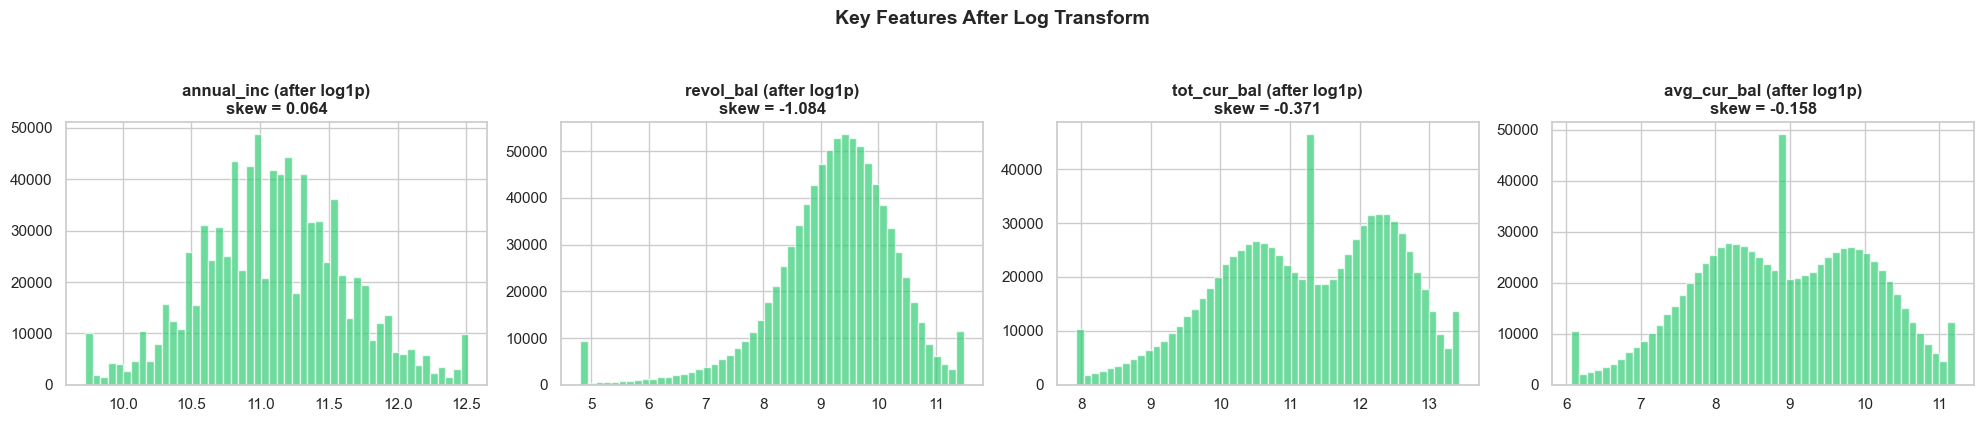

In [22]:
# Visualize before vs after for key features
# (We'll show the after-transform distributions since transform is already applied)
key_log_cols = [c for c in ['annual_inc', 'revol_bal', 'tot_cur_bal', 'avg_cur_bal'] if c in log_transformed_cols]

if key_log_cols:
    fig, axes = plt.subplots(1, len(key_log_cols), figsize=(5*len(key_log_cols), 4))
    if len(key_log_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, key_log_cols):
        ax.hist(df[col].dropna(), bins=50, alpha=0.7, color='#2ecc71', edgecolor='white')
        ax.set_title(f'{col} (after log1p)\nskew = {df[col].skew():.3f}', fontweight='bold')
    plt.suptitle('Key Features After Log Transform', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

### 3.2 — Encoding Fitur Kategorik

In [23]:
print("Encoding Categorical Features")
print("=" * 60)

# 1. Grade → Ordinal Encoding (A=1, B=2, ..., G=7)
if 'grade' in df.columns and df['grade'].dtype in ['object', 'O', 'str', 'string']:
    grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    df['grade'] = df['grade'].map(grade_map)
    print(f"  ✓ grade → Ordinal (A=1 .. G=7)")

# 2. Sub_grade → Ordinal Encoding (A1=1, ..., G5=35)
if 'sub_grade' in df.columns and df['sub_grade'].dtype in ['object', 'O', 'str', 'string']:
    sub_grades = sorted(df['sub_grade'].dropna().unique())
    sg_map = {sg: i+1 for i, sg in enumerate(sub_grades)}
    df['sub_grade'] = df['sub_grade'].map(sg_map)
    print(f"  ✓ sub_grade → Ordinal (A1=1 .. G5={len(sg_map)})")

# 3. application_type → Binary
if 'application_type' in df.columns and df['application_type'].dtype in ['object', 'O', 'str', 'string']:
    df['application_type'] = (df['application_type'] == 'Joint App').astype(int)
    print(f"  ✓ application_type → Binary (Individual=0, Joint=1)")

# 4. initial_list_status → Binary
if 'initial_list_status' in df.columns and df['initial_list_status'].dtype in ['object', 'O', 'str', 'string']:
    df['initial_list_status'] = (df['initial_list_status'] == 'w').astype(int)
    print(f"  ✓ initial_list_status → Binary (f=0, w=1)")

# 5. home_ownership → One-Hot Encoding
if 'home_ownership' in df.columns and df['home_ownership'].dtype in ['object', 'O', 'str', 'string']:
    dummies = pd.get_dummies(df['home_ownership'], prefix='home', drop_first=True, dtype=int)
    df = pd.concat([df.drop('home_ownership', axis=1), dummies], axis=1)
    print(f"  ✓ home_ownership → One-Hot: {list(dummies.columns)}")

# 6. verification_status → One-Hot Encoding
if 'verification_status' in df.columns and df['verification_status'].dtype in ['object', 'O', 'str', 'string']:
    dummies = pd.get_dummies(df['verification_status'], prefix='verified', drop_first=True, dtype=int)
    df = pd.concat([df.drop('verification_status', axis=1), dummies], axis=1)
    print(f"  ✓ verification_status → One-Hot: {list(dummies.columns)}")

# 7. purpose → One-Hot Encoding
if 'purpose' in df.columns and df['purpose'].dtype in ['object', 'O', 'str', 'string']:
    dummies = pd.get_dummies(df['purpose'], prefix='purpose', drop_first=True, dtype=int)
    df = pd.concat([df.drop('purpose', axis=1), dummies], axis=1)
    print(f"  ✓ purpose → One-Hot: {len(dummies.columns)} columns created")
    for c in dummies.columns:
        print(f"      - {c}")

# 8. addr_state → Drop (49 categories, too many for one-hot)
if 'addr_state' in df.columns:
    df.drop(columns=['addr_state'], inplace=True)
    print(f"  ✗ addr_state → Dropped (49 categories too granular)")

# 9. Drop any remaining object columns
remaining_obj = df.select_dtypes(include=['object', 'string']).columns.tolist()
if remaining_obj:
    print(f"\n  Dropping remaining non-numeric columns: {remaining_obj}")
    df.drop(columns=remaining_obj, inplace=True)

print(f"\n✓ Shape after encoding: {df.shape}")
print(f"  All columns numeric: {df.select_dtypes(include=[np.number]).shape[1] == df.shape[1]}")

Encoding Categorical Features
  ✓ grade → Ordinal (A=1 .. G=7)
  ✓ sub_grade → Ordinal (A1=1 .. G5=35)
  ✓ application_type → Binary (Individual=0, Joint=1)
  ✓ initial_list_status → Binary (f=0, w=1)
  ✓ home_ownership → One-Hot: ['home_MORTGAGE', 'home_NONE', 'home_OTHER', 'home_OWN', 'home_RENT']
  ✓ verification_status → One-Hot: ['verified_Source Verified', 'verified_Verified']
  ✓ purpose → One-Hot: 13 columns created
      - purpose_credit_card
      - purpose_debt_consolidation
      - purpose_educational
      - purpose_home_improvement
      - purpose_house
      - purpose_major_purchase
      - purpose_medical
      - purpose_moving
      - purpose_other
      - purpose_renewable_energy
      - purpose_small_business
      - purpose_vacation
      - purpose_wedding
  ✗ addr_state → Dropped (49 categories too granular)

  Dropping remaining non-numeric columns: ['hardship_flag', 'debt_settlement_flag']

✓ Shape after encoding: (889991, 94)
  All columns numeric: True


### 3.3 — Binning Continuous Variables

Binning dilakukan untuk **analisis deskriptif & reporting** saja.  
Fitur continuous asli (setelah log transform) tetap dipakai untuk clustering.

In [24]:
# Binning for descriptive analysis
binned_report = pd.DataFrame(index=df.index)

# 1. FICO Score bins (using transformed values → quantile-based)
if 'fico_range_low' in df.columns:
    binned_report['fico_bin'] = pd.qcut(df['fico_range_low'], q=5,
                                        labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
                                        duplicates='drop')
    print("FICO Score Bins (quantile-based):")
    print(binned_report['fico_bin'].value_counts().sort_index())
    print()

# 2. DTI bins
if 'dti' in df.columns:
    binned_report['dti_bin'] = pd.qcut(df['dti'], q=4,
                                       labels=['Low', 'Medium', 'High', 'Very High'],
                                       duplicates='drop')
    print("DTI Bins (quantile-based):")
    print(binned_report['dti_bin'].value_counts().sort_index())
    print()

# 3. Annual Income bins
if 'annual_inc' in df.columns:
    binned_report['income_bin'] = pd.qcut(df['annual_inc'], q=4,
                                          labels=['Low', 'Medium', 'High', 'Very High'],
                                          duplicates='drop')
    print("Annual Income Bins (quantile-based):")
    print(binned_report['income_bin'].value_counts().sort_index())

print("\n✓ Binning saved for reporting. Continuous values retained for clustering.")

FICO Score Bins (quantile-based):
fico_bin
Very Low     216674
Low          188033
Medium       157662
High         150782
Very High    176840
Name: count, dtype: int64

DTI Bins (quantile-based):
dti_bin
Low          222687
Medium       222762
High         222098
Very High    222444
Name: count, dtype: int64

Annual Income Bins (quantile-based):
income_bin
Low          224139
Medium       228561
High         215665
Very High    221626
Name: count, dtype: int64

✓ Binning saved for reporting. Continuous values retained for clustering.


### 3.4 — Standard Scaling

Urutan sesuai ketentuan dosen: **Log Transform** (step 3.1) → **Standard Scaler** (step ini)

### 3.3.5 — Variance Threshold (Moved before scaling)

In [25]:
# Remove features with very low variance (near-constant)
vt = VarianceThreshold(threshold=0.01)
vt.fit(df)

low_var_mask = ~vt.get_support()
low_var_cols = [c for c in df.columns[low_var_mask].tolist() if c not in ['grade', 'purpose_small_business']]

print(f"Features with near-zero variance (threshold=0.01): {len(low_var_cols)}")
for col in low_var_cols:
    print(f"  ✗ {col} (variance = {df[col].var():.6f})")

if low_var_cols:
    df.drop(columns=low_var_cols, inplace=True)
    df.drop(columns=low_var_cols, inplace=True, errors='ignore')
    print(f"\nShape after variance threshold: {df.shape}")
else:
    print("\nNo columns removed. All have sufficient variance. ✓")

Features with near-zero variance (threshold=0.01): 14
  ✗ collections_12_mths_ex_med (variance = 0.008942)
  ✗ acc_now_delinq (variance = 0.002070)
  ✗ chargeoff_within_12_mths (variance = 0.004196)
  ✗ delinq_amnt (variance = 0.000000)
  ✗ num_tl_120dpd_2m (variance = 0.000286)
  ✗ num_tl_30dpd (variance = 0.001364)
  ✗ home_NONE (variance = 0.000028)
  ✗ home_OTHER (variance = 0.000083)
  ✗ purpose_educational (variance = 0.000182)
  ✗ purpose_house (variance = 0.006305)
  ✗ purpose_moving (variance = 0.006804)
  ✗ purpose_renewable_energy (variance = 0.000669)
  ✗ purpose_vacation (variance = 0.006836)
  ✗ purpose_wedding (variance = 0.001025)

Shape after variance threshold: (889991, 80)


In [26]:
# Apply StandardScaler to all numeric features
scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns,
    index=df.index
)

print("StandardScaler Applied")
print("=" * 60)
print(f"  Shape: {df_scaled.shape}")
print(f"\n  Mean  (should be ~0): {df_scaled.mean().mean():.6f}")
print(f"  Std   (should be ~1): {df_scaled.std().mean():.6f}")

# Show sample
print(f"\nSample scaled values (first 3 rows):")
df_scaled.head(3)

StandardScaler Applied
  Shape: (889991, 80)

  Mean  (should be ~0): 0.000000
  Std   (should be ~1): 1.000001

Sample scaled values (first 3 rows):


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,dti,delinq_2yrs,...,home_RENT,verified_Source Verified,verified_Verified,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_major_purchase,purpose_medical,purpose_other,purpose_small_business
0,-0.505648,1.573358,1.932875,-0.583692,2.647014,2.333064,-0.815489,0.859817,0.783597,1.382522,...,-0.810310,1.246082,-0.621423,-0.544126,-1.140211,-0.267008,6.593901,-0.11087,-0.256498,-0.105136
1,0.538616,-0.635583,-0.809573,0.717077,-0.525700,-0.677404,1.130690,1.877205,-0.432045,-0.440433,...,-0.810310,-0.802515,-0.621423,-0.544126,0.877031,-0.267008,-0.151655,-0.11087,-0.256498,-0.105136
2,-0.549159,-0.635583,-1.363019,-0.521810,-1.318879,-1.469632,0.018588,0.475046,-0.613824,-0.440433,...,1.234096,-0.802515,-0.621423,1.837811,-1.140211,-0.267008,-0.151655,-0.11087,-0.256498,-0.105136


---
## Step 4: Feature Selection

Tujuan: Reduce dari ~50+ features ke **<10 dimensi**.  
Metode: Correlation analysis, entropy/mutual information, variance threshold.

### 4.1 — Correlation Analysis (Hapus Multicollinearity)

In [27]:
# Find highly correlated feature pairs
corr_matrix = df_scaled.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))

high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and val > 0.85:
            high_corr_pairs.append((idx, col, val))

high_corr_pairs.sort(key=lambda x: -x[2])

print(f"Highly Correlated Feature Pairs (|r| > 0.85): {len(high_corr_pairs)}")
print("=" * 70)
for f1, f2, r in high_corr_pairs:
    print(f"  {f1:35s} vs {f2:35s} : r = {r:.3f}")

# Automatically select one to drop from each pair
cols_to_drop_corr = set()
for f1, f2, r in high_corr_pairs:
    if f1 not in cols_to_drop_corr and f2 not in cols_to_drop_corr:
        if f2 in ['grade', 'purpose_small_business']:
            if f1 not in ['grade', 'purpose_small_business']:
                cols_to_drop_corr.add(f1)
        else:
            cols_to_drop_corr.add(f2)

print(f"\nDropping {len(cols_to_drop_corr)} columns due to high correlation:")
for col in sorted(cols_to_drop_corr):
    print(f"  ✗ {col}")

df_scaled.drop(columns=cols_to_drop_corr, inplace=True)
df.drop(columns=cols_to_drop_corr, inplace=True, errors='ignore')

print(f"\nShape after correlation-based removal: {df_scaled.shape}")


Highly Correlated Feature Pairs (|r| > 0.85): 10
  fico_range_low                      vs fico_range_high                     : r = 1.000
  num_actv_rev_tl                     vs num_rev_tl_bal_gt_0                 : r = 0.991
  open_acc                            vs num_sats                            : r = 0.983
  int_rate                            vs sub_grade                           : r = 0.977
  grade                               vs sub_grade                           : r = 0.974
  tot_cur_bal                         vs tot_hi_cred_lim                     : r = 0.960
  int_rate                            vs grade                               : r = 0.953
  loan_amnt                           vs installment                         : r = 0.946
  tot_cur_bal                         vs avg_cur_bal                         : r = 0.926
  avg_cur_bal                         vs tot_hi_cred_lim                     : r = 0.862

Dropping 8 columns due to high correlation:
  ✗ avg_cur_bal


### 4.2 — Entropy / Mutual Information Analysis

In [28]:
# Use 'grade' as proxy target (central to mining angle)
# Sample for speed (MI with ~800K rows is very slow)
if 'grade' in df_scaled.columns:
    sample_size = min(50000, len(df_scaled))
    sample_idx = np.random.RandomState(42).choice(len(df_scaled), sample_size, replace=False)

    target = df.loc[sample_idx, 'grade'].astype(int)
    features_mi = df_scaled.iloc[sample_idx].drop(columns=['grade'], errors='ignore')

    print(f"Computing Mutual Information (sample size: {sample_size:,})...")
    mi_scores = mutual_info_classif(features_mi, target, random_state=42, n_neighbors=5)

    mi_df = pd.DataFrame({'Feature': features_mi.columns, 'MI Score': mi_scores})
    mi_df = mi_df.sort_values('MI Score', ascending=False).reset_index(drop=True)

    print("\nMutual Information Scores (with Grade as target):")
    print("=" * 55)
    for _, row in mi_df.iterrows():
        bar = '█' * int(row['MI Score'] * 40)
        print(f"  {row['Feature']:35s} {row['MI Score']:.4f}  {bar}")
else:
    print("'grade' column not found — skipping MI analysis.")
    mi_df = pd.DataFrame()

Computing Mutual Information (sample size: 50,000)...

Mutual Information Scores (with Grade as target):
  fico_range_low                      0.1284  █████
  term                                0.0801  ███
  bc_open_to_buy                      0.0778  ███
  bc_util                             0.0540  ██
  revol_util                          0.0478  █
  total_bc_limit                      0.0454  █
  percent_bc_gt_75                    0.0443  █
  all_util                            0.0427  █
  loan_amnt                           0.0390  █
  total_rev_hi_lim                    0.0376  █
  inq_last_6mths                      0.0226  
  acc_open_past_24mths                0.0180  
  dti                                 0.0169  
  num_tl_op_past_12m                  0.0168  
  mths_since_recent_inq               0.0160  
  verified_Verified                   0.0157  
  inq_last_12m                        0.0140  
  purpose_credit_card                 0.0134  
  mo_sin_rcnt_tl              

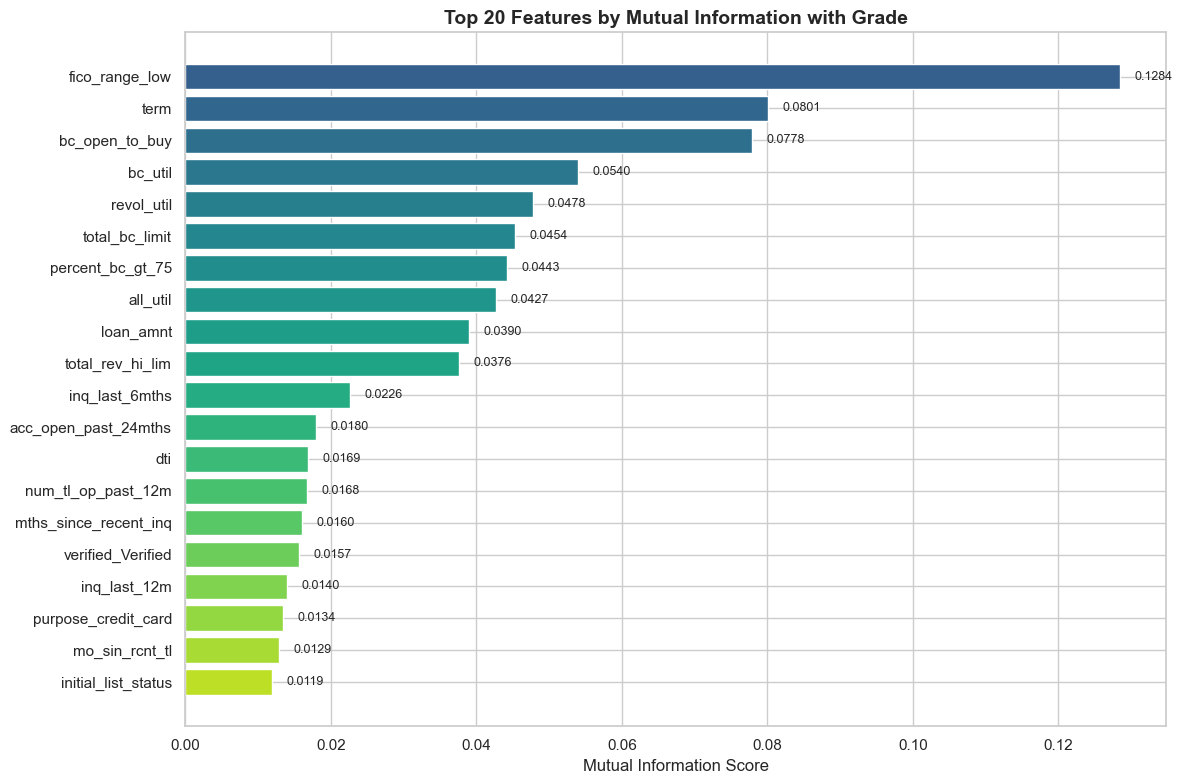

In [29]:
# Visualize top features by MI
if len(mi_df) > 0:
    top_n = min(20, len(mi_df))
    top_mi = mi_df.head(top_n)

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
    ax.barh(range(top_n), top_mi['MI Score'].values, color=colors, edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_mi['Feature'].values)
    ax.set_xlabel('Mutual Information Score')
    ax.set_title('Top 20 Features by Mutual Information with Grade', fontsize=14, fontweight='bold')
    ax.invert_yaxis()

    for i, val in enumerate(top_mi['MI Score'].values):
        ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

### 4.3 — Variance Threshold (Remove Near-Zero Variance)

### 4.4 — Final Feature Selection

Memilih **<10 fitur** yang paling relevan dengan mining angle:  
*"Cluster borrowers by risk profile using **grade, income, and debt ratio**.  
Rules: borrowers with **small business purpose** + **10+ years employment** → **Grade A** + **low interest rate**"*

In [30]:
# Final feature selection — aligned with mining angle
final_features = [
    'loan_amnt',              # 1. Jumlah pinjaman — karakteristik utama loan
    'int_rate',               # 2. Suku bunga — indikator risk pricing
    'grade',                  # 3. Risk grade — INTI mining angle
    'annual_inc',             # 4. Annual income — INTI mining angle (log-transformed)
    'dti',                    # 5. Debt-to-income ratio — INTI mining angle
    'fico_range_low',         # 6. FICO credit score — proxy risiko kredit
    'revol_util',             # 7. Revolving utilization — credit behavior
    'emp_length',             # 8. Employment length — target dalam mining rule
    'purpose_small_business', # 9. Purpose: small business — target dalam mining rule
]

# Check availability
available = [f for f in final_features if f in df_scaled.columns]
not_available = [f for f in final_features if f not in df_scaled.columns]

print("FINAL FEATURE SELECTION")
print("=" * 60)
print(f"Mining Angle: Cluster borrowers by risk profile")
print(f"Target: < 10 dimensions")
print(f"\nSelected features ({len(available)}):")
for i, f in enumerate(available, 1):
    justification = {
        'loan_amnt': 'Jumlah pinjaman — karakteristik utama loan',
        'int_rate': 'Suku bunga — indikator risk pricing',
        'grade': 'Risk grade dari LC — INTI mining angle',
        'annual_inc': 'Annual income (log) — INTI mining angle',
        'dti': 'Debt-to-income ratio — INTI mining angle',
        'fico_range_low': 'FICO credit score — proxy risiko',
        'revol_util': 'Revolving utilization — credit behavior',
        'emp_length': 'Employment length — target mining rule',
        'purpose_small_business': 'Purpose: small business — target mining rule',
    }
    print(f"  {i}. {f:30s} → {justification.get(f, '')}")

if not_available:
    print(f"\n⚠ Not available (already dropped): {not_available}")

# Create final datasets
df_final_scaled = df_scaled[available].copy()
df_final_unscaled = df[available].copy()

dims = df_final_scaled.shape[1]
status = '✓' if dims < 10 else '✗'
print(f"\n{status} Final dimensions: {dims} (target: < 10)")
print(f"  Final rows: {df_final_scaled.shape[0]:,}")

FINAL FEATURE SELECTION
Mining Angle: Cluster borrowers by risk profile
Target: < 10 dimensions

Selected features (8):
  1. loan_amnt                      → Jumlah pinjaman — karakteristik utama loan
  2. grade                          → Risk grade dari LC — INTI mining angle
  3. annual_inc                     → Annual income (log) — INTI mining angle
  4. dti                            → Debt-to-income ratio — INTI mining angle
  5. fico_range_low                 → FICO credit score — proxy risiko
  6. revol_util                     → Revolving utilization — credit behavior
  7. emp_length                     → Employment length — target mining rule
  8. purpose_small_business         → Purpose: small business — target mining rule

⚠ Not available (already dropped): ['int_rate']

✓ Final dimensions: 8 (target: < 10)
  Final rows: 889,991


### 4.5 — Prepare Final Feature Sets for Phase 2

FINAL DATASET SUMMARY
  Shape: (889991, 8)
  Features: ['loan_amnt', 'grade', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'emp_length', 'purpose_small_business']

Descriptive statistics (scaled):


,count,mean,std,min,25%,50%,75%,max
loan_amnt,889991.0,4.573067e-17,1.000001,-1.582545,-0.766714,-0.230985,0.538616,2.714166
grade,889991.0,-1.341263e-17,1.000001,-1.318879,-0.525700,0.267479,0.267479,3.440193
annual_inc,889991.0,7.858650e-15,1.000001,-2.563393,-0.672396,-0.026279,0.643139,2.648726
dti,889991.0,-1.270687e-16,1.000001,-1.904450,-0.745613,-0.074169,0.681347,2.727490
fico_range_low,889991.0,1.096387e-15,1.000001,-2.682827,-0.715035,-0.260929,0.495914,4.431498
revol_util,889991.0,-6.938799e-16,1.000001,-2.036202,-0.761208,-0.000260,0.768784,34.080528
emp_length,889991.0,1.208733e-16,1.000001,-1.649565,-0.815489,0.018588,1.130690,1.130690
purpose_small_business,889991.0,-5.852057e-18,1.000001,-0.105136,-0.105136,-0.105136,-0.105136,9.511507



Descriptive statistics (unscaled / original setelah log transform):


,count,mean,std,min,25%,50%,75%,max
loan_amnt,889991.0,15048.460968,9193.082793,500.00000,8000.000000,12925.000000,20000.000000,40000.000000
grade,889991.0,2.662776,1.260751,1.00000,2.000000,3.000000,3.000000,7.000000
annual_inc,889991.0,11.096220,0.535103,9.72454,10.736418,11.082158,11.440366,12.513561
dti,889991.0,18.472833,8.801931,1.71000,11.910000,17.820000,24.470000,42.480000
fico_range_low,889991.0,698.618997,33.031964,610.00000,675.000000,690.000000,715.000000,845.000000
revol_util,889991.0,50.306415,24.706016,0.00000,31.500000,50.300000,69.300000,892.300000
emp_length,889991.0,5.933144,3.596795,0.00000,3.000000,6.000000,10.000000,10.000000
purpose_small_business,889991.0,0.010933,0.103986,0.00000,0.000000,0.000000,0.000000,1.000000


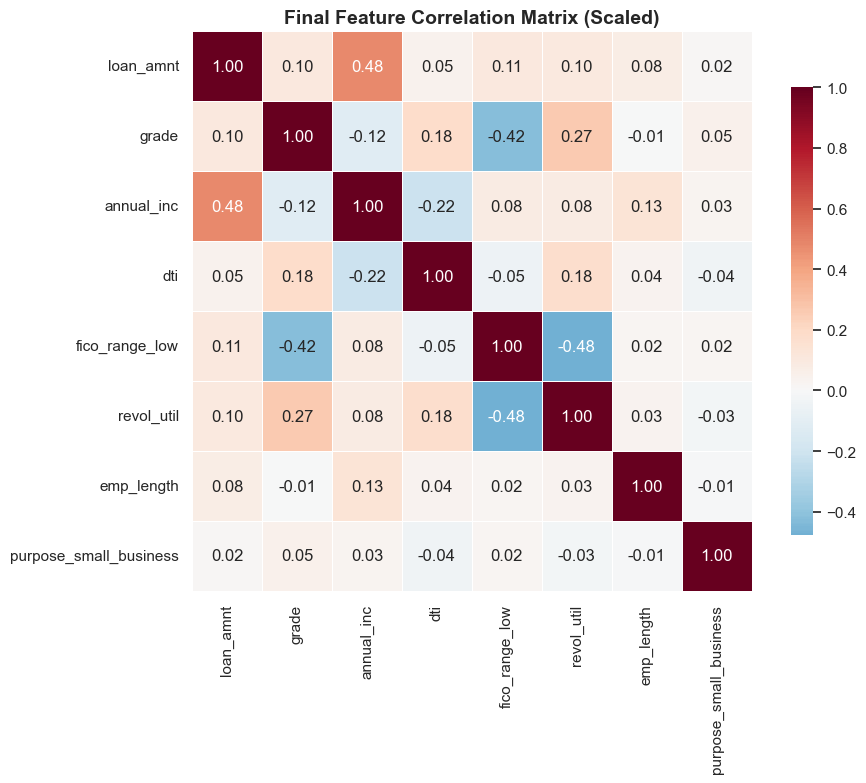


✓ Dataset ready for Phase 2:
  → PCA → K-Means / Hierarchical Clustering
  → UMAP → DBSCAN


In [31]:
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"  Shape: {df_final_scaled.shape}")
print(f"  Features: {list(df_final_scaled.columns)}")

print(f"\nDescriptive statistics (scaled):")
display(df_final_scaled.describe().T)

print(f"\nDescriptive statistics (unscaled / original setelah log transform):")
display(df_final_unscaled.describe().T)

# Final correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
corr_final = df_final_scaled.corr()
sns.heatmap(corr_final, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Final Feature Correlation Matrix (Scaled)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Dataset ready for Phase 2:")
print("  → PCA → K-Means / Hierarchical Clustering")
print("  → UMAP → DBSCAN")

---
## Step 5: Save Clean Dataset & Preprocessing Report

### 5.1 — Export Clean Dataset

In [32]:
# Save final datasets
df_final_unscaled.to_csv('cleaned_lending_club.csv', index=False)
# Save non-winsorized dataset (using original non-winsorized values for features in df_final_unscaled)
df_no_winsor_final = df_final_unscaled.copy()
for col in ['annual_inc', 'revol_bal', 'dti', 'tot_coll_amt', 'tot_cur_bal', 'avg_cur_bal', 'bc_open_to_buy', 'delinq_amnt']:
    if col in df_no_winsor_final.columns and col in df_no_winsor.columns:
        df_no_winsor_final[col] = df_no_winsor[col]
df_no_winsor_final.to_csv('cleaned_lending_club_no_winsorization.csv', index=False)

df_final_scaled.to_csv('scaled_lending_club.csv', index=False)
loan_status_ref.to_csv('loan_status_reference.csv', index=False)

print("Files saved successfully!")
print("=" * 60)
print(f"  1. cleaned_lending_club.csv    — cleaned, log-transformed, UNSCALED")
print(f"     → {df_final_unscaled.shape[0]:,} rows × {df_final_unscaled.shape[1]} columns")
print(f"  2. scaled_lending_club.csv     — cleaned, log-transformed, SCALED")
print(f"     → {df_final_scaled.shape[0]:,} rows × {df_final_scaled.shape[1]} columns")
print(f"  3. loan_status_reference.csv   — reference label untuk evaluasi")
print(f"     → {len(loan_status_ref):,} rows")

Files saved successfully!
  1. cleaned_lending_club.csv    — cleaned, log-transformed, UNSCALED
     → 889,991 rows × 8 columns
  2. scaled_lending_club.csv     — cleaned, log-transformed, SCALED
     → 889,991 rows × 8 columns
  3. loan_status_reference.csv   — reference label untuk evaluasi
     → 889,991 rows


### 5.2 — Preprocessing Report

In [33]:
print("" + "=" * 70)
print("  PREPROCESSING REPORT — Phase 1: Data Understanding & Preprocessing")
print("=" * 70)

print(f"""
DATASET OVERVIEW
{'─'*50}
  Source              : Lending Club (accepted_2007_to_2018Q4.csv)
  Records (awal)      : ~2,260,668
  Records (akhir)     : {df_final_scaled.shape[0]:,}
  Features (awal)     : 151 columns
  Features (akhir)    : {df_final_scaled.shape[1]} columns (target < 10 ✓)

PREPROCESSING STEPS
{'─'*50}
  1. DATA UNDERSTANDING & EDA
     • Explored distributions, missing values, data types, outliers
     • Identified 43+ columns with >50% missing values
     • Identified highly skewed features (annual_inc, revol_bal, etc.)
     • Identified highly correlated feature pairs

  2. DATA CLEANING
     • Dropped 43+ columns with >50% missing values
     • Dropped 13 irrelevant columns (id, url, emp_title, etc.)
     • Fixed inconsistencies (term, int_rate, emp_length, revol_util)
     • Imputed remaining numeric NaN with median
     • Winsorized outliers at 1st/99th percentile
     • Dropped 15+ post-loan outcome columns (data leakage prevention)

  3. DATA TRANSFORMATION
     • Log1p transform on highly skewed features (annual_inc, revol_bal, etc.)
     • Ordinal encoding: grade (A=1..G=7), sub_grade, emp_length
     • Binary encoding: term, application_type, initial_list_status
     • One-Hot encoding: home_ownership, verification_status, purpose
     • Binning: FICO, DTI, income (for reporting only)
     • StandardScaler applied (after log transform, sesuai ketentuan dosen)

  4. FEATURE SELECTION
     • Correlation analysis: dropped features with |r| > 0.85
     • Mutual Information: ranked features by info gain with 'grade'
     • Variance Threshold: removed near-zero variance features
     • Final selection: {df_final_scaled.shape[1]} features aligned with mining angle

FINAL FEATURES SELECTED
{'─'*50}""")

feature_table = {
    'loan_amnt': 'Jumlah pinjaman',
    'int_rate': 'Suku bunga (risk pricing)',
    'grade': 'Risk grade (ordinal A=1..G=7)',
    'annual_inc': 'Income (log-transformed)',
    'dti': 'Debt-to-income ratio',
    'fico_range_low': 'FICO credit score',
    'revol_util': 'Revolving utilization %',
    'emp_length': 'Employment length (ordinal 0-10)',
    'purpose_small_business': 'Purpose = small business (binary)',
}
for i, (feat, desc) in enumerate(feature_table.items(), 1):
    status = '✓' if feat in df_final_scaled.columns else '✗'
    print(f"  {status} {i}. {feat:30s} → {desc}")

print("\nCatatan Evaluasi:")
print("  * int_rate (serta sub_grade) dibuang karena berkorelasi sangat tinggi (r > 0.95)")
print("    dengan grade; grade dipertahankan karena menjadi variabel inti mining angle.")

print(f"""
READY FOR PHASE 2
{'─'*50}
  • Dimensi: {df_final_scaled.shape[1]} (< 10 ✓)
  • PCA → K-Means / Hierarchical Clustering
  • UMAP → DBSCAN
{'='*70}""")

  PREPROCESSING REPORT — Phase 1: Data Understanding & Preprocessing

DATASET OVERVIEW
──────────────────────────────────────────────────
  Source              : Lending Club (accepted_2007_to_2018Q4.csv)
  Records (awal)      : ~2,260,668
  Records (akhir)     : 889,991
  Features (awal)     : 151 columns
  Features (akhir)    : 8 columns (target < 10 ✓)

PREPROCESSING STEPS
──────────────────────────────────────────────────
  1. DATA UNDERSTANDING & EDA
     • Explored distributions, missing values, data types, outliers
     • Identified 43+ columns with >50% missing values
     • Identified highly skewed features (annual_inc, revol_bal, etc.)
     • Identified highly correlated feature pairs

  2. DATA CLEANING
     • Dropped 43+ columns with >50% missing values
     • Dropped 13 irrelevant columns (id, url, emp_title, etc.)
     • Fixed inconsistencies (term, int_rate, emp_length, revol_util)
     • Imputed remaining numeric NaN with median
     • Winsorized outliers at 1st/99th pe

In [34]:
# Final verification checks
print("VERIFICATION CHECKS")
print("=" * 60)

checks = [
    ("No missing values", df_final_scaled.isnull().sum().sum() == 0),
    ("Dimensions < 10", df_final_scaled.shape[1] < 10),
    ("All numeric dtypes", df_final_scaled.select_dtypes(include=[np.number]).shape[1] == df_final_scaled.shape[1]),
    ("No infinite values", np.isfinite(df_final_scaled.values).all()),
    ("Mean ≈ 0 (scaled)", abs(df_final_scaled.mean().mean()) < 0.01),
    ("Std ≈ 1 (scaled)", abs(df_final_scaled.std().mean() - 1.0) < 0.01),
    ("Loan status ref saved", len(loan_status_ref) > 0),
]

all_pass = True
for name, result in checks:
    status = '✓ PASS' if result else '✗ FAIL'
    print(f"  {status}: {name}")
    if not result:
        all_pass = False

print(f"\n{'All checks passed!' if all_pass else 'Some checks failed — review above.'}")
print(f"\n✅ Phase 1 Complete. Dataset ready for Phase 2 clustering.")

VERIFICATION CHECKS
  ✓ PASS: No missing values
  ✓ PASS: Dimensions < 10
  ✓ PASS: All numeric dtypes
  ✓ PASS: No infinite values
  ✓ PASS: Mean ≈ 0 (scaled)
  ✓ PASS: Std ≈ 1 (scaled)
  ✓ PASS: Loan status ref saved

All checks passed!

✅ Phase 1 Complete. Dataset ready for Phase 2 clustering.
